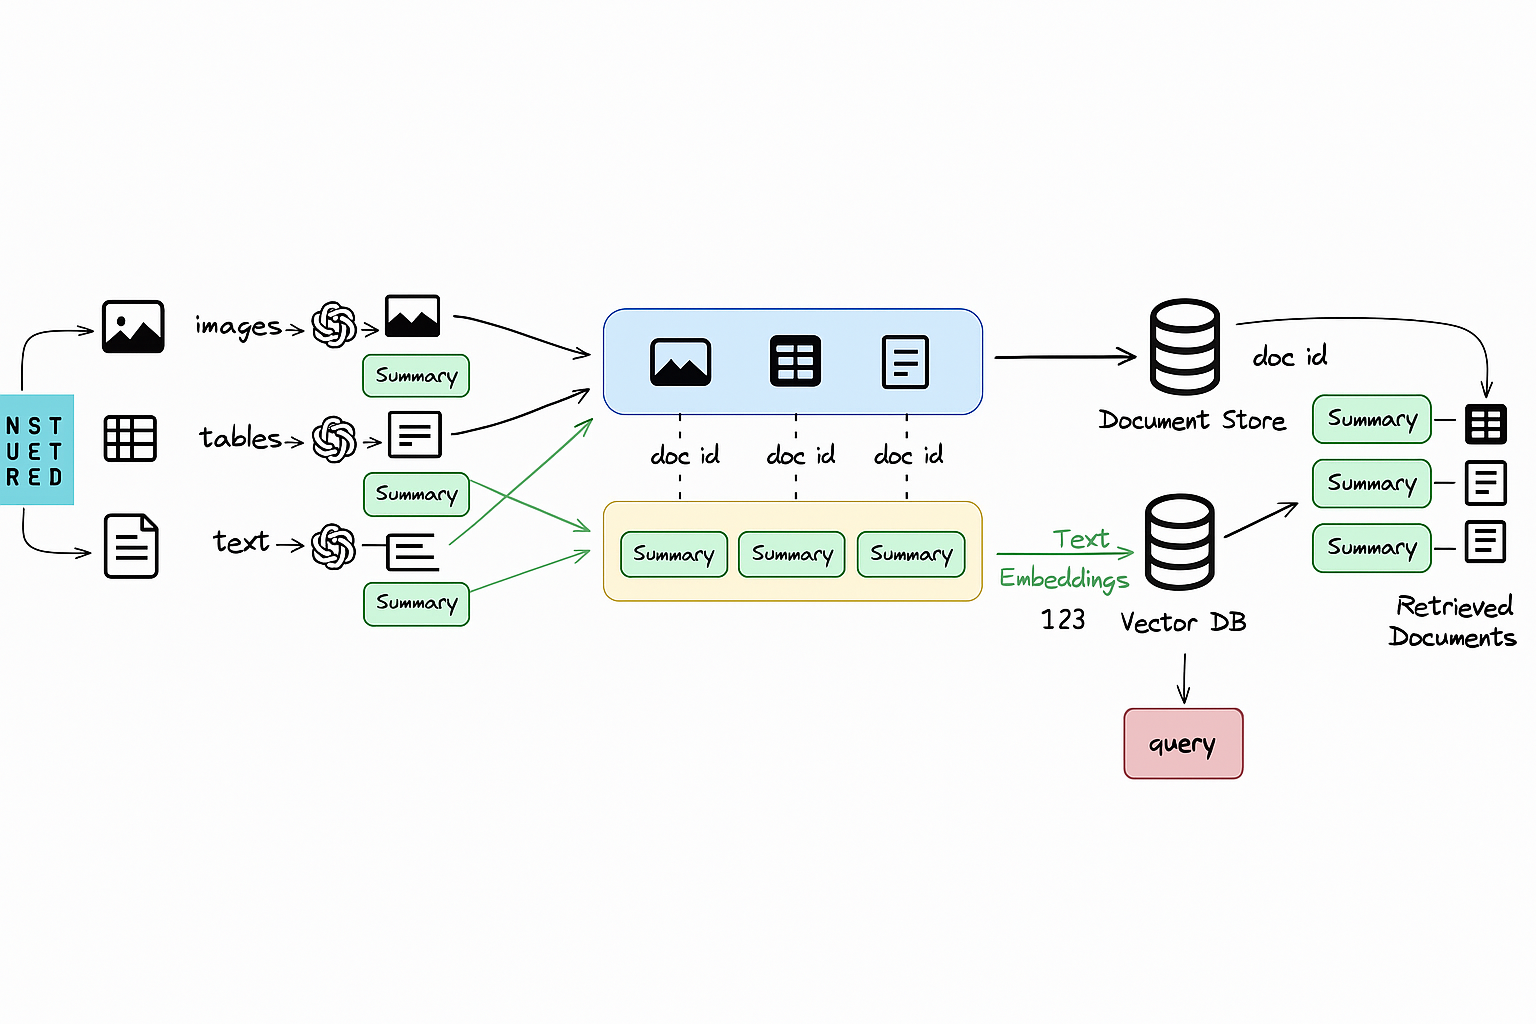

In [109]:
import uuid
import numpy as np
import pytesseract
from unstructured.partition.pdf import partition_pdf
pytesseract.pytesseract.tesseract_cmd = 'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'

In [110]:
def extract_content(pdf_path):
    
    elements = partition_pdf(
        filename=pdf_path,
        infer_table_structure=True,
        strategy="hi_res",
        extract_image_block_types=["Image"],
        # image_output_dir_path="./Output/",
        extract_image_block_to_payload=True,
        chunking_strategy="by_title",
        max_characters=10000,
        combine_text_under_n_chars=2000,
        new_after_n_chars=6000
    )
    return elements

In [111]:
elements = extract_content("Data\\Attention is all you need.pdf")
# elements = extract_content("Data\\LE_Filled.pdf")

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

In [112]:
print(elements[0])

3

2023

2

0

2

g u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0

7

1

:

v

arXiv

i

X

r

a

Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.

Attention Is All You Need

Ashish Vaswani∗

Google Brain

avaswani@google.com

Noam Shazeer∗ Google Brain noam@google.com

Niki Parmar∗ Google Research nikip@google.com

Jakob Uszkoreit∗

Google Research usz@google.com

Llion Jones∗

Google Research llion@google.com

Aidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu

Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com

Illia Polosukhin∗ ‡

illia.polosukhin@gmail.com

Abstract

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the 

In [113]:
elements[0].metadata.to_dict()

{'filetype': 'application/pdf',
 'languages': ['eng'],
 'last_modified': '2025-03-31T13:19:04',
 'page_number': 1,
 'orig_elements': 'eJzNW+uP3LYR/1eI+9QCxwXfj3yKE7hpWtc1Yrtp4QYGRVK7qrXSVdKefS76v3dIatd7D7d3F+i6AZz1jPgY/mY4D5J+96+z2MZt7Kb3TTj7Bp05T6Uj1GCptcBCWYqrijEcuIpSRFtby87O0dk2Ti64yUGff535vh9C07kpjplu3VW/m95vYrPeTMBhjBDoM7M/NmHaAJfqzL3om25K/d69E3IlzpG0YsV+OUczqRhbkURSQlb2Nl2aA+NsvBqnuE2reNV8iu3rC+fj2b/hQ920cbq6iPnTqz+dZVm69c6ts8DvzmK3Pvslc8fp/bYPTd3EDAcjTGLCMadvKP+G2m+ISL0voOf7bret4pAWkuaY4qe01DOevu8ne9t5AGXdD83nGN6kFtD0JuRRRKeq6HDQLmBReYWNMQpXNqhgla9s7ReDXNIVSRjagmkhNeGFNOYOsjQ+GcChx8MxrxkgK+qIo2cVFsQRbLmNWNLK26q2ptJ2YTM/2PFMCrsyx2Z+k87NTwf1h5u590RRTXGIocYiEostoRoHaYmQhhLr+dKQ7zGdSa1X6hjim3RufjKQkwdDzoMAnLnCTjBw5kxRbIWAaWUdjK91FejSzvyAaSE1kSt+BPFNujQ/GcgfbuUCfHitFXgSFhxYuQrYhtpjrSpqBKtkzZa2ck3tcfykXIhrZn2LUTr8V9BDnKKfmr577wHW8f3F0FfQjKyEYYw+sVbWaIeeIYZ+QS/Q92iFRuTRO6TRJfAU/HJEgKvQtQ3z++gCDHWHylilqkpyUFmUFAtdV9i4FImtERALOKVMLqyyrJJrOtN0Za/p7BZDnFTaox+8UxykNlJyjz2PFgtRO2w9c7gOLkbNSV

In [251]:
set([str(type(el)) for el in elements])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [252]:
elements[5].metadata.orig_elements

In [201]:
elements[5].metadata.orig_elements[1].text

'In addition to attention sub-layers, each of the layers in our encoder and decoder contains a fully connected feed-forward network, which is applied to each position separately and identically. This consists of two linear transformations with a ReLU activation in between.'

In [ ]:
chunk = elements[5].metadata.orig_elements
chunk_tables = [ch for ch in chunk if 'Table' in str(type(ch))]
chunk_tables[0].to_dict()

{'type': 'Table',
 'element_id': '5cd1c9d5-0b86-4481-a2eb-7bd38b31e3dd',
 'text': 'Layer Type Complexity per Layer Sequential Maximum Path Length Operations Self-Attention O(n2 · d) O(1) O(1) Recurrent O(n · d2) O(n) O(n) Convolutional O(k · n · d2) O(1) O(logk(n)) Self-Attention (restricted) O(r · n · d) O(1) O(n/r)',
 'metadata': {'detection_class_prob': 0.928255021572113,
  'coordinates': {'points': ((np.float64(320.3292236328125),
     np.float64(312.45477294921875)),
    (np.float64(320.3292236328125), np.float64(519.1640014648438)),
    (np.float64(1363.9827880859375), np.float64(519.1640014648438)),
    (np.float64(1363.9827880859375), np.float64(312.45477294921875))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2025-03-31T13:19:04',
  'text_as_html': '<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Attention</td><td>

In [118]:
chunk = elements[3].metadata.orig_elements
chunk_images = [ch for ch in chunk if 'Image' in str(type(ch))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': '502a9fbe-91be-480d-a756-c8c12352e194',
 'text': '',
 'metadata': {'coordinates': {'points': ((np.float64(486.0),
     np.float64(261.1805555555558)),
    (np.float64(486.0), np.float64(614.7805555555556)),
    (np.float64(664.0), np.float64(614.7805555555556)),
    (np.float64(664.0), np.float64(261.1805555555558))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2025-03-31T13:19:04',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 4,
  'image_base64': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCAFiALIDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJ

In [257]:
def get_multimodal_data():
    texts, tables, images_b64 = [], [], []
    for element in elements:
        if 'CompositeElement' in str(type(element)):
            element_chunk = element.metadata.orig_elements
            flag = True
            for chunk in element_chunk:
                if 'Table' in str(type(chunk)):
                    # flag = False
                    tables.append(chunk.metadata.text_as_html)
                    
                elif 'Image' in str(type(chunk)):
                    # flag = False
                    images_b64.append(chunk.metadata.image_base64)
            if flag:
                texts.append(element)

    return texts, tables, images_b64    

In [258]:
texts, tables, images_b64 = get_multimodal_data()

In [259]:
print(f"Number of texts: {len(texts)}")
print(f"Number of tables: {len(tables)}")
print(f"Number of images: {len(images_b64)}")

Number of texts: 12
Number of tables: 4
Number of images: 7


In [260]:
print(texts[9])

big

6

1024

4096

16

0.3

300K 4.33

26.4

development set, newstest2013. We used beam search as described in the previous section, but no checkpoint averaging. We present these results in Table 3.

In Table 3 rows (A), we vary the number of attention heads and the attention key and value dimensions, keeping the amount of computation constant, as described in Section 3.2.2. While single-head attention is 0.9 BLEU worse than the best setting, quality also drops off with too many heads.

In Table 3 rows (B), we observe that reducing the attention key size dk hurts model quality. This suggests that determining compatibility is not easy and that a more sophisticated compatibility function than dot product may be beneficial. We further observe in rows (C) and (D) that, as expected, bigger models are better, and dropout is very helpful in avoiding over-fitting. In row (E) we replace our sinusoidal positional encoding with learned positional embeddings [9], and observe nearly identical res

In [123]:
print(f"Table: {tables[0]}")

Table: <table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Attention</td><td>O(n? - d)</td><td>O(1)</td><td>O(1)</td></tr><tr><td>Recurrent</td><td>O(n- d?)</td><td>O(n)</td><td>O(n)</td></tr><tr><td>Convolutional</td><td>O(k-n-d?)</td><td>O(1)</td><td>O(logy(n))</td></tr><tr><td>Self-Attention (restricted)</td><td>O(r-n-d)</td><td>ol)</td><td>O(n/r)</td></tr></tbody></table>


In [124]:
print(f"Image: {images_b64[0]}")

Image: ...


In [125]:
import base64
from IPython.display import Image, display

In [126]:
def display_base64_image(base64_image):
    image_data = base64.b64decode(base64_image)
    display(Image(data=image_data))

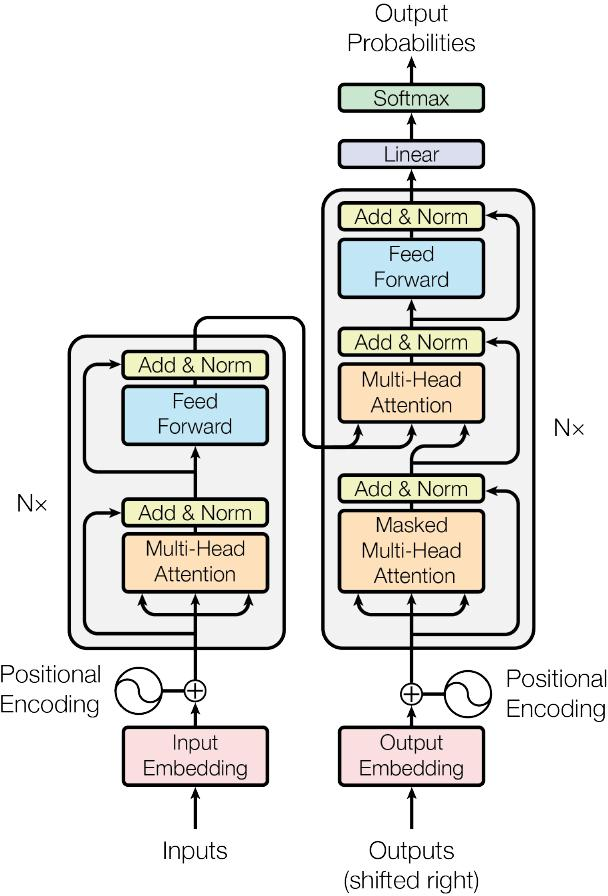

In [127]:
display_base64_image(images_b64[0])

In [128]:
import pandas as pd
from io import StringIO
from bs4 import BeautifulSoup

In [129]:
soup = BeautifulSoup(tables[0], 'html.parser')
mesa = soup.find(name='table')
df = pd.read_html(StringIO(str(mesa)), displayed_only=False)

In [130]:
print(df)

[                    Layer Type Complexity per Layer Sequential Operations  \
0               Self-Attention            O(n? - d)                  O(1)   
1                    Recurrent             O(n- d?)                  O(n)   
2                Convolutional            O(k-n-d?)                  O(1)   
3  Self-Attention (restricted)             O(r-n-d)                   ol)   

  Maximum Path Length  
0                O(1)  
1                O(n)  
2          O(logy(n))  
3              O(n/r)  ]
